In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| Device:', device)


# 1. AutoEncoder

### 1-1. AutoEncoder 설명

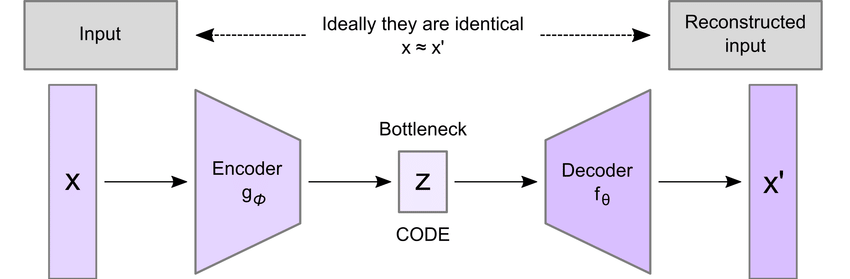

고차원의 입력 데이터를 저차원의 잠재 표현 벡터로 축소하기 위해 제안된 비지도 학습

*   '입력 데이터'를 '잠재 표현 벡터'로 압축시켰다가 다시 '최대한 입력 데이터와 유사한 데이터'를 복원하도록 네트워크 업데이트
  1. Encoder: 고차원의 입력 데이터를 저차원의 잠재 표현 벡터로 압축
  2. Decoder: 저차원의 잠재 표현 벡터로 최대한 입력 데이터와 유사한 데이터를 생성

*   입력 데이터와 출력 데이터의 차이(재구축 오차, Reconstruction Error)를 최소화하도록 네트워크 업데이트


▶ 차원 축소, 노이즈 제거, 이상 탐지, 추천 시스템 등에 활용

### 1-2. Setting (Library, Data)

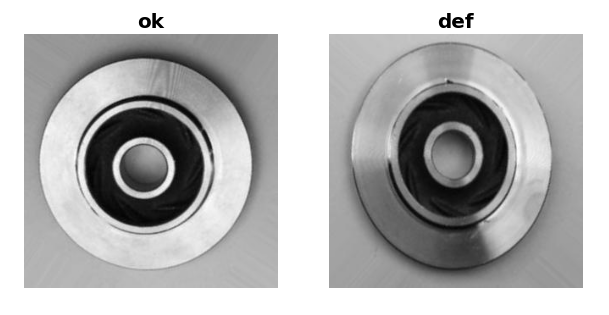

데이터는 casting 제조 데이터로, casing 결함 검사를 자동화하기 위해 수집된 데이터이다.
- Casting은 일반적으로 액체 재료를 원하는 모양의 금형(틀)에 붓고 응고시키는 제조 공정이다.
- Casting 결함은 금속 casting 공정에서 발생하는 이상 패턴으로, 블로우 홀, 핀홀, 버, 수축 결함, 금형 재료 결함, 쏟아지는 금속 결함, 야금 결함 등 많은 유형의 결함이 있다.
- 이 결함 제품을 제거하기 위해 품질 검사 부서가 있지만, 이 검사 프로세스는 수동으로 수행되어 시간이 많이 걸리고 사람의 주관적인 판단이 개입되기 때문에 100% 정확하지 않다.

모든 데이터는 512x512의 사이즈를 가지며, Train 데이터는 정상 419개, Test 데이터는 정상/비정상 100개씩 존재한다.

In [ ]:
# 정상 데이터만 불러오기

root_path ='' #경로복사
path = os.path.join(root_path,'Dataset/Casting_Product')

data_tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # rescale 1./255
])

full_ds = datasets.ImageFolder(os.path.join(path,'train'), transform=data_tf)
n_total = len(full_ds)
n_val = int(n_total * 0.2)
n_train = n_total - n_val
train_ds, valid_ds = random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=16, shuffle=False)


In [ ]:
x_train, y_train = next(iter(train_loader))
x_valid, y_valid = next(iter(valid_loader))


In [ ]:
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)


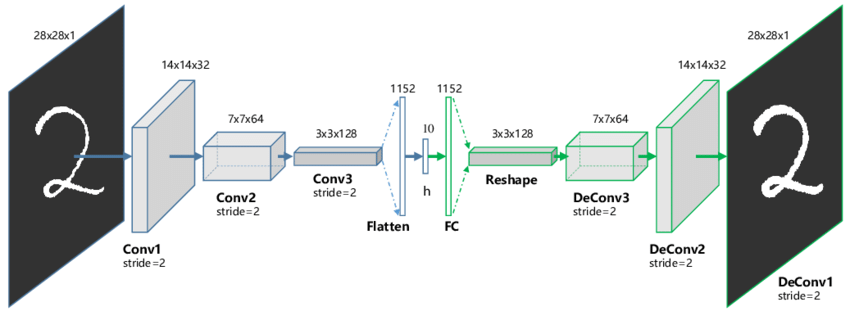

Basic AutoEncoder와 구조는 동일하지만, Convolution을 활용하여 인코더와 디코더를 구성

*   Encoder: 이미지를 잠재 표현 벡터로 압축 (convolutional layer를 활용)
*   Decoder: 잠재 표현 벡터로 최대한 입력 이미지와 유사한 이미지를 생성 (transposed convolutional layer를 활용)

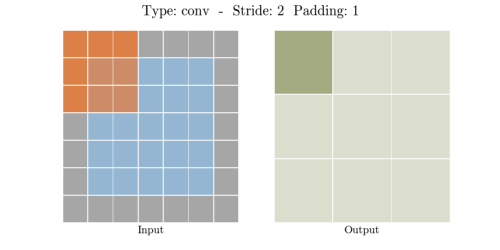

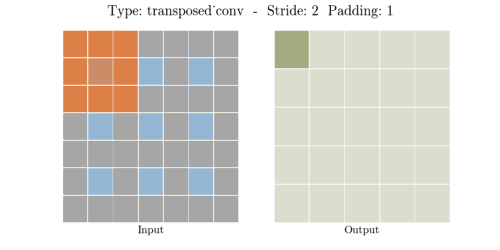

In [ ]:
class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder 정의
        self.features = nn.Sequential(
            # 입력 데이터의 크기는 224x224, 채널은 1
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            # 필터 수 32, 필터 크기 3x3, 패딩은 same, 스트라이드는 2
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            # 필터 수 64, 필터 크기 3x3, 패딩은 same, 스트라이드는 2
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            # 필터 수 128, 필터 크기 3x3, 패딩은 same, 스트라이드는 2
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            # 필터 수 256, 필터 크기 3x3, 패딩은 same, 스트라이드는 2
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(),
            # 출력을 1차원으로 변환
            nn.Flatten(),
            # 1024개의 뉴런을 가진 은닉층, 활성화 함수는 relu
            nn.Linear(7 * 7 * 256, 1024), nn.ReLU(),
            # 512개의 뉴런을 가진 은닉층, 활성화 함수는 relu
            nn.Linear(1024, 512), nn.ReLU(),
            # 출력층, 256개의 뉴런을 가진 은닉층, 활성화 함수는 relu
            nn.Linear(512, 256), nn.ReLU(),
        )

    def forward(self, x):
        return self.features(x)


class ConvDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Decoder 정의
        self.fc = nn.Sequential(
            # 입력 데이터는 256차원 벡터
            nn.Linear(256, 512), nn.ReLU(),
            # 1024개의 뉴런을 가진 은닉층, 활성화 함수는 relu
            nn.Linear(512, 1024), nn.ReLU(),
            # 7x7x256 크기의 3D 텐서로 변환
            nn.Linear(1024, 7 * 7 * 256), nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            # 7x7x256 크기의 3D 텐서를 7x7x256 크기의 4D 텐서로 변환 후 확대
            # Transposed Convolution 연산을 수행하여 이미지를 확대
            nn.ConvTranspose2d(256, 256, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            # 출력 이미지의 채널 수는 1
            nn.Conv2d(16, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 7, 7)
        return self.deconv(x)


class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ConvEncoder()
        self.decoder = ConvDecoder()

    def forward(self, x):
        return self.decoder(self.encoder(x))


# Encoder와 Decoder를 연결하여 모델 정의
encoder = ConvEncoder()
decoder = ConvDecoder()
convautoencoder = ConvAutoEncoder().to(device)


In [ ]:
print(encoder)
print(decoder)


In [ ]:
cae_criterion = nn.MSELoss()
cae_optimizer = torch.optim.Adam(convautoencoder.parameters())


In [ ]:
weights_dir = Path(os.path.join(root_path,'weights'))
weights_dir.mkdir(exist_ok=True)
best_cae_val = float('inf')

In [ ]:
def fit_conv_ae(model, train_loader, valid_loader, epochs=50, patience=5):
    global best_cae_val
    wait = 0
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            cae_optimizer.zero_grad()
            recon = model(x)
            loss = cae_criterion(recon, x)
            loss.backward()
            cae_optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in valid_loader:
                x = x.to(device)
                recon = model(x)
                val_loss += cae_criterion(recon, x).item() * x.size(0)
        val_loss /= len(valid_loader.dataset)

        if val_loss < best_cae_val:
            best_cae_val = val_loss
            torch.save(model.state_dict(), weights_dir / f'weights.{epoch:02d}-{val_loss:.2f}.pt')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

        if epoch % 1 == 0:
            print(f'Epoch {epoch:02d} loss={train_loss:.4f} val_loss={val_loss:.4f}')



In [ ]:
fit_conv_ae(convautoencoder, train_loader, valid_loader, epochs=50, patience=15)

In [ ]:
save_path = weights_dir / 'weight_final.pt'
torch.save(convautoencoder.state_dict(), save_path)
print('saved:', save_path)

In [ ]:
# convautoencoder.load_state_dict(torch.load('path'))  # 저장한 weights 모델에 load


In [ ]:
x_valid, y_valid = next(iter(valid_loader))
convautoencoder.eval()
with torch.no_grad():
    reconstructed = convautoencoder(x_valid.to(device)).cpu()


In [ ]:
i = 1
plt.subplot(1, 2, 1)
plt.imshow(reconstructed[i, 0].numpy(), cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(x_valid[i, 0].numpy(), cmap='gray')
plt.show()


# 3. Applications

## 3-1. Anomaly Detection using Convolutional AutoEncoder

### Normal Test 데이터 원본과 복원 이미지 시각화

In [ ]:
test_tf = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

test_normal_ds = datasets.ImageFolder(os.path.join(path ,'test' ,'normal'), transform=test_tf)
test_normal_loader = DataLoader(test_normal_ds, batch_size=100, shuffle=False)


In [ ]:
normal_test, _ = next(iter(test_normal_loader))


In [ ]:
normal_test.shape


In [ ]:
plt.imshow(normal_test[0, 0].numpy(), cmap='gray')
plt.show()


In [ ]:
convautoencoder.eval()
with torch.no_grad():
    recon = convautoencoder(normal_test.to(device)).cpu()
plt.imshow(recon[0, 0].numpy(), cmap='gray')  # 복원된 이미지
plt.show()


### Abormal Test 데이터 원본과 복원 이미지 시각화

In [ ]:
test_abnormal_ds = datasets.ImageFolder(os.path.join(path , 'test' , 'abnormal'), transform=test_tf)
test_abnormal_loader = DataLoader(test_abnormal_ds, batch_size=100, shuffle=False)


In [ ]:
abnormal_test, _ = next(iter(test_abnormal_loader))


In [ ]:
plt.imshow(abnormal_test[0, 0].numpy(), cmap='gray')
plt.show()


In [ ]:
with torch.no_grad():
    recon_ab = convautoencoder(abnormal_test.to(device)).cpu()
plt.imshow(recon_ab[0, 0].numpy(), cmap='gray')
plt.show()


In [ ]:
"""정상 Test 데이터의 원본과 복원 MAE 분포 확인"""
convautoencoder.eval()
with torch.no_grad():
    reconstructions = convautoencoder(normal_test.to(device)).cpu()
flat_recon = reconstructions.view(reconstructions.size(0), -1)
flat_orig = normal_test.view(normal_test.size(0), -1)
test_normal_loss = F.l1_loss(flat_recon, flat_orig, reduction='none').mean(dim=1).numpy()

plt.hist(test_normal_loss, bins=30)
plt.xlabel('Test normal loss')
plt.ylabel('No of examples')
plt.show()


In [ ]:
abnormal_test.shape


In [ ]:
"""비정상 Test 데이터의 원본과 복원 MAE 분포 확인"""
with torch.no_grad():
    reconstructions = convautoencoder(abnormal_test.to(device)).cpu()
flat_recon = reconstructions.view(reconstructions.size(0), -1)
flat_orig = abnormal_test.view(abnormal_test.size(0), -1)
test_abnormal_loss = F.l1_loss(flat_recon, flat_orig, reduction='none').mean(dim=1).numpy()

plt.hist(test_abnormal_loss, bins=30)
plt.xlabel('Test abnormal loss')
plt.ylabel('No of examples')
plt.show()


In [ ]:
"""겹쳐서 보기"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1-1. Multiple histograms on the same axis
sns.histplot(test_abnormal_loss, color='red', label='Abnormal', kde=True, stat='density', alpha=0.4)
sns.histplot(test_normal_loss, color='blue', label='Normal', kde=True, stat='density', alpha=0.4)
plt.legend()
plt.show()
